In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/14986.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/3138.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/1700.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/16257.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/2863.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/771.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/12167.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/17643.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/6560.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/10162.jpg
/kaggl

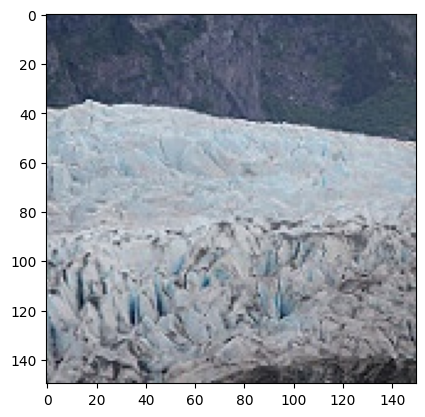

In [2]:
import matplotlib.pyplot as plt
import cv2
path=r"/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/glacier/20287.jpg"
image=cv2.imread(path)
image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
plt.imshow(image)


(np.float64(-0.5), np.float64(149.5), np.float64(149.5), np.float64(-0.5))

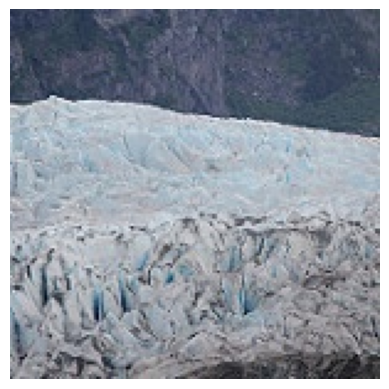

In [3]:
####next image in matplotlib
from PIL import Image 
image=Image.open(path)
plt.imshow(image)
plt.axis('off')


In [4]:
dataset_path=r"/kaggle/input/datasets/puneet6060/intel-image-classification"
classe=os.listdir(dataset_path)
print(classe)


['seg_train', 'seg_pred', 'seg_test']


In [5]:
print("The total classs is ",os.listdir("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/"))

The total classs is  ['mountain', 'street', 'buildings', 'sea', 'forest', 'glacier']


In [12]:
imagees=cv2.imread(r"/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/sea/20072.jpg")
train_path = os.path.join(base_path, "seg_train", "seg_train")
test_path = os.path.join(base_path, "seg_test", "seg_test")

print("Train classes:")
print(os.listdir(train_path))

print("Test classes:")
print(os.listdir(test_path))

Train classes:
['mountain', 'street', 'buildings', 'sea', 'forest', 'glacier']
Test classes:
['mountain', 'street', 'buildings', 'sea', 'forest', 'glacier']


In [20]:
classes = [
    folder for folder in os.listdir(train_path)
    if os.path.isdir(os.path.join(train_path, folder))
]

print(classes)

['mountain', 'street', 'buildings', 'sea', 'forest', 'glacier']


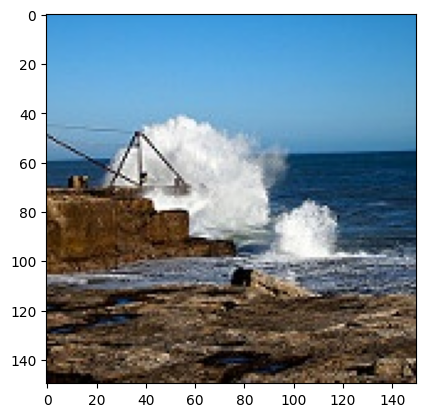

In [13]:
imagees=cv2.cvtColor(imagees,cv2.COLOR_BGR2RGB)
plt.imshow(imagees)

In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255
)

train_data = datagen.flow_from_directory(
    train_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode="categorical"
)

Found 14034 images belonging to 6 classes.


In [15]:
datagen=ImageDataGenerator(
    rescale=1./255
)
test_data=datagen.flow_from_directory(
    test_path,
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical"
)

Found 3000 images belonging to 6 classes.


In [17]:
images, labels = next(test_data)

print(images.shape)

(32, 128, 128, 3)


In [25]:
import cv2
import os
import numpy as np

sift = cv2.SIFT_create(nfeatures=500)

sift_features = []
sift_labels = []

for label, class_name in enumerate(classes):

    class_path = os.path.join(train_path, class_name)

    print("Processing:", class_name)

    for image_name in os.listdir(class_path):

        image_path = os.path.join(class_path, image_name)

        image = cv2.imread(image_path)

        if image is None:
            continue

        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        keypoints, descriptors = sift.detectAndCompute(gray, None)

        if descriptors is not None:
            sift_features.append(descriptors)
            sift_labels.append(label)

print("Number of images:", len(sift_features))
print("Number of labels:", len(sift_labels))

Processing: mountain
Processing: street
Processing: buildings
Processing: sea
Processing: forest
Processing: glacier
Number of images: 14024
Number of labels: 14024


In [26]:
print("Number of images:", len(sift_features))
print("Number of labels:", len(sift_labels))

Number of images: 14024
Number of labels: 14024


In [29]:
from sklearn.cluster import MiniBatchKMeans
import numpy as np

all_sift_descriptors = np.vstack(sift_features).astype(np.float32)

print("All descriptors shape:", all_sift_descriptors.shape)

All descriptors shape: (2161164, 128)


In [30]:
k = 100

sift_kmeans = MiniBatchKMeans(
    n_clusters=k,
    random_state=42,
    batch_size=1000
)

sift_kmeans.fit(all_sift_descriptors)

MiniBatchKMeans(batch_size=1000, n_clusters=100, random_state=42)

In [31]:
X_sift = []

for descriptors in sift_features:

    visual_words = sift_kmeans.predict(descriptors)

    histogram = np.bincount(
        visual_words,
        minlength=k
    )

    X_sift.append(histogram)

X_sift = np.array(X_sift)
y_sift = np.array(sift_labels)

print("SIFT feature shape:", X_sift.shape)
print("SIFT labels shape:", y_sift.shape)

SIFT feature shape: (14024, 100)
SIFT labels shape: (14024,)


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_sift,
    y_sift,
    test_size=0.2,
    random_state=42,
    stratify=y_sift
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (11219, 100)
X_test: (2805, 100)


In [33]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

models = {
    "SVM": SVC(kernel="rbf"),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    
    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),
    
    "Logistic Regression": LogisticRegression(
        max_iter=1000
    )
}

In [34]:
from sklearn.metrics import accuracy_score

results = {}

for name, model in models.items():

    print("Training:", name)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results[name] = accuracy

    print(name, "Accuracy:", accuracy)

Training: SVM
SVM Accuracy: 0.613903743315508
Training: Random Forest
Random Forest Accuracy: 0.5522281639928699
Training: KNN
KNN Accuracy: 0.4823529411764706
Training: Logistic Regression
Logistic Regression Accuracy: 0.5793226381461676


In [35]:
print("\nModel Comparison:")

for name, accuracy in results.items():
    print(f"{name}: {accuracy:.4f}")


Model Comparison:
SVM: 0.6139
Random Forest: 0.5522
KNN: 0.4824
Logistic Regression: 0.5793


SVM Accuracy: 0.6139


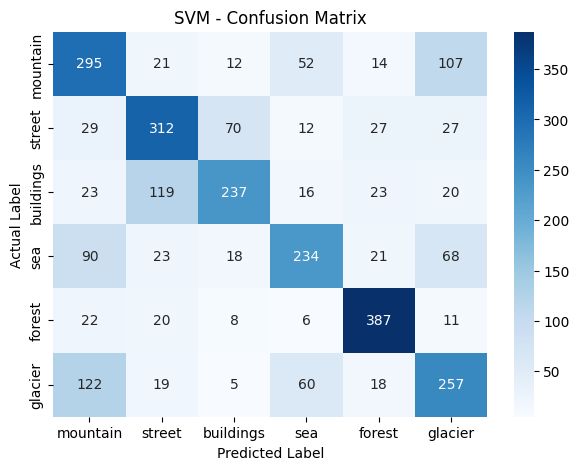

Random Forest Accuracy: 0.5522


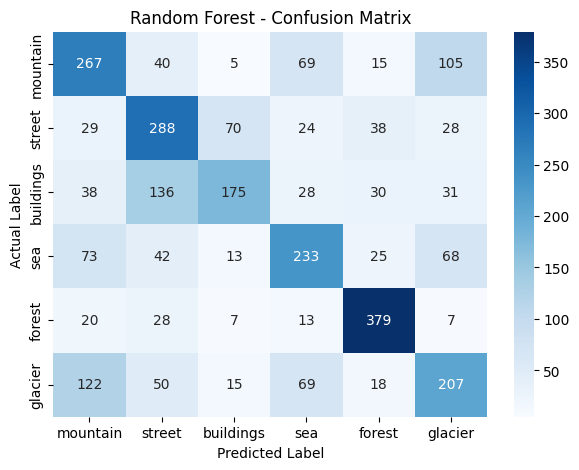

KNN Accuracy: 0.4824


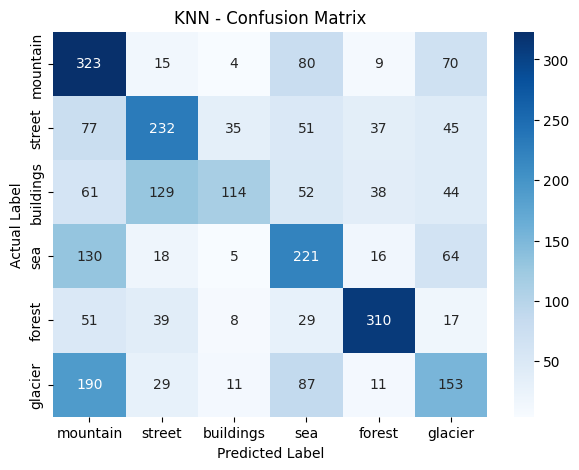

Logistic Regression Accuracy: 0.5793


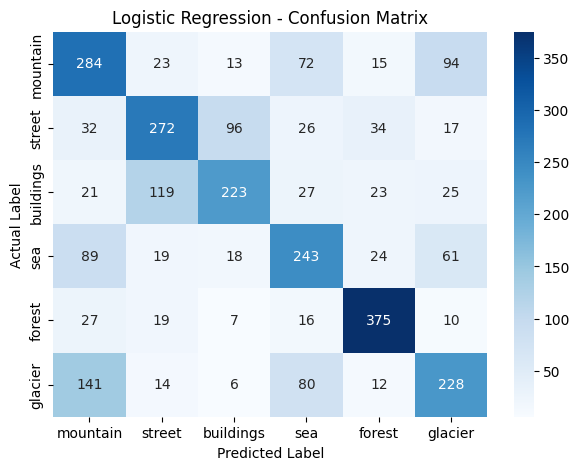

In [36]:
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

for name, model in models.items():

    # Prediction
    y_pred = model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)

    print(f"{name} Accuracy: {accuracy:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(7, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes
    )

    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.show()

In [37]:
import joblib

# Find best model
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

# Save
joblib.dump(best_model, "best_model.pkl")

print("Best Model:", best_model_name)
print("Best Accuracy:", results[best_model_name])
print("Model saved as best_model.pkl")

Best Model: SVM
Best Accuracy: 0.613903743315508
Model saved as best_model.pkl


In [38]:
import os

print(os.path.exists("/kaggle/working/best_model.pkl"))

True
